In [1]:
#import modules 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn import set_config
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

set_config(print_changed_only=False) # changes some print outputs slightly(not important)
df = pd.read_csv(r"knee_injur_&_playerStats_NBA2010-2020_nolabel.csv") #import the data set and assign it to a data frame df

z = df[['poscode','age','g','gs','mp','fga','p3a','p2a','fta','orb','drb','trb','ast','stl','blk','pf']] #used for diagrams



In [2]:
position_map = {
    1: 'PG',
    2: 'SG',
    3: 'SF',
    4: 'PF',
    5: 'C'
}
df['poscode'] = df['poscode'].map(position_map)

# By listing 'PG' first in the categories list, we ensure it is index 0.
df['poscode'] = pd.Categorical(
    df['poscode'], 
    categories=['PG', 'SG', 'SF', 'PF', 'C'], 
    ordered=True
)

# drop_first=True will now drop index 0, which we just set to 'PG' so that PG becomes the baseline
df_encoded = pd.get_dummies(df, columns=['poscode'], prefix='Position', drop_first=True)  

y = df_encoded['svrkneeinjury']  #we want to predict y(severe knee injuries)

base_features = ['age','g','gs','mp','p3a','p2a','fta','trb','ast','stl','blk','pf']      # predictor variables used to predict y

position_features = [col for col in df_encoded.columns if col.startswith('Position_')]

X = df_encoded[position_features + base_features]


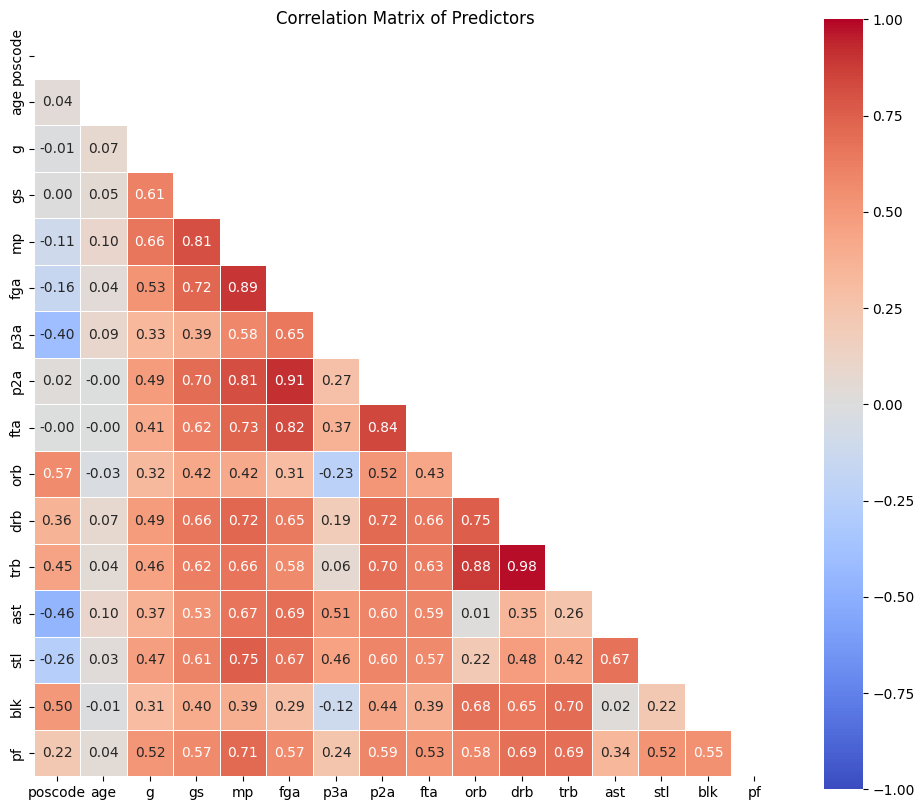

In [3]:
#diagram to show potential colinearity in predictor variables
corrmatrix = z.corr()      
plt.figure(figsize=(12, 10))

# Create a mask to hide the upper triangle (since it's a mirror image)
mask = np.triu(np.ones_like(corrmatrix, dtype=bool))

sns.heatmap(
    corrmatrix, 
    mask=mask, 
    annot=True,        # Show the numbers
    fmt=".2f",         # Format to 2 decimal places
    cmap='coolwarm',   # Red/Blue allows easy spotting of strong correlations
    vmin=-1, vmax=1,   # Fix scale from -1 to 1
    center=0,
    square=True,
    linewidths=.5
)

plt.title('Correlation Matrix of Predictors')
plt.show()

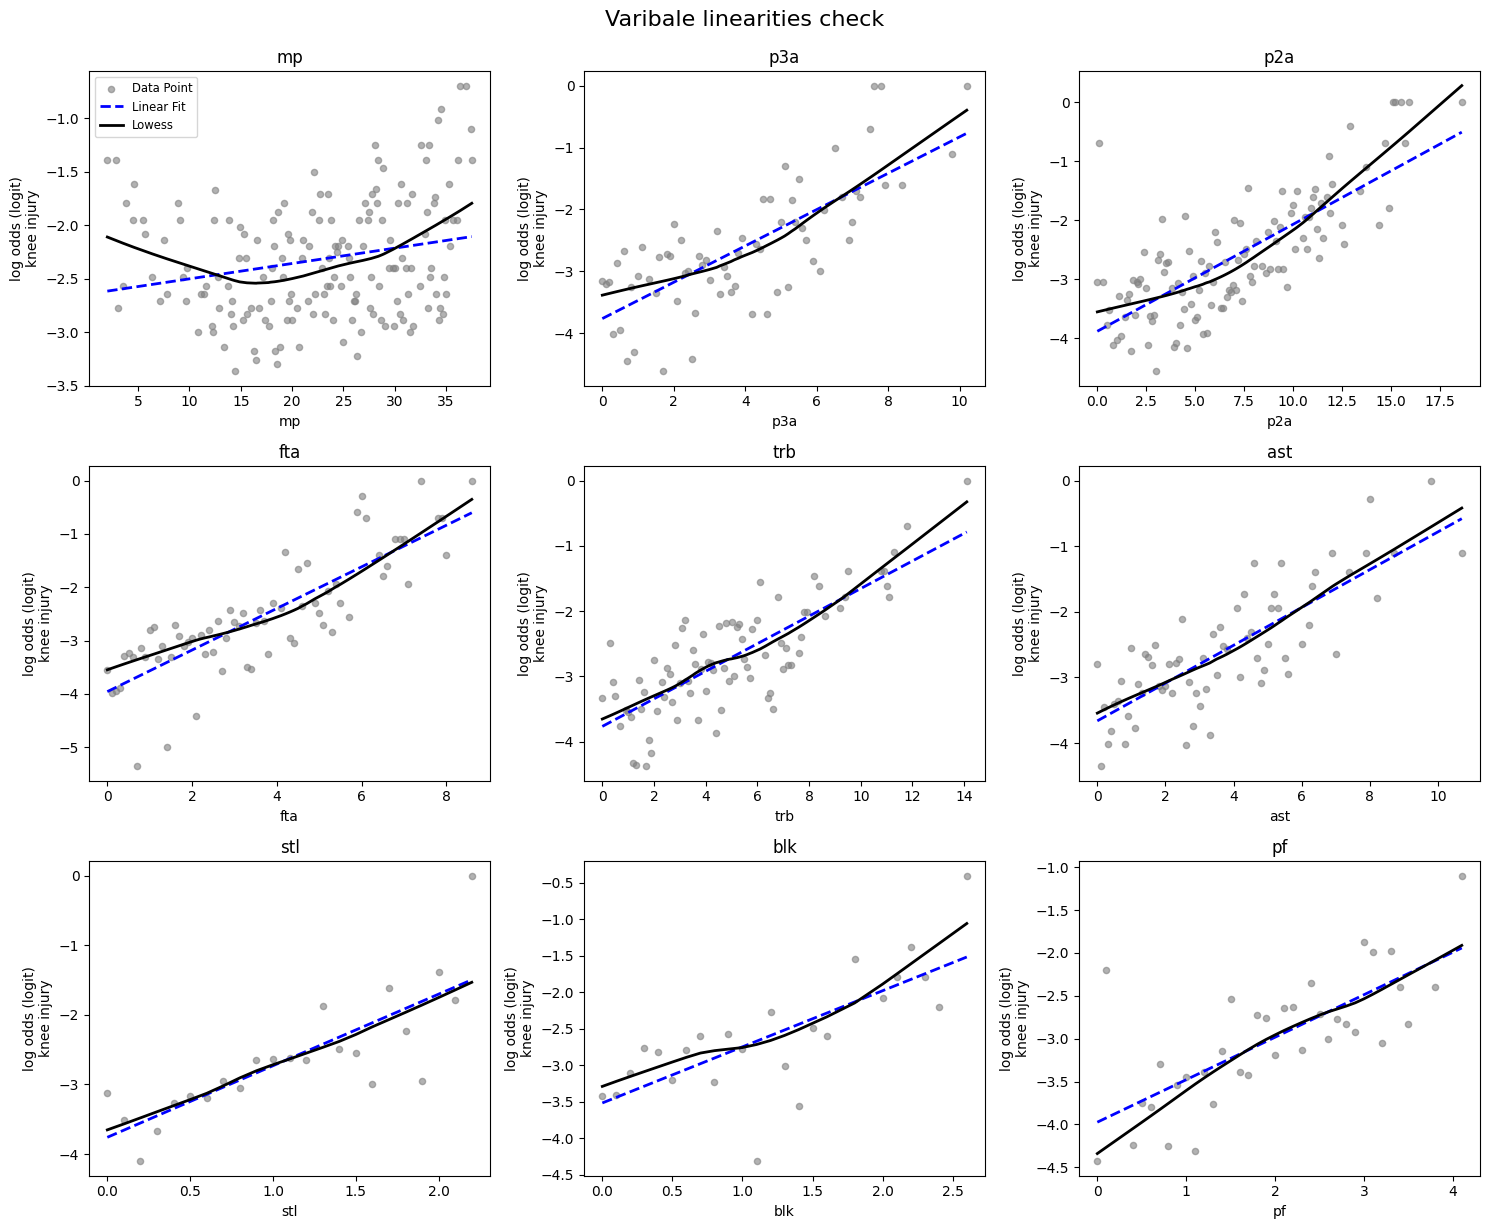

In [4]:
import statsmodels.api as sm
from statsmodels.formula.api import logit
import matplotlib.pyplot as plt

continuous_vars = ['mp', 'p3a', 'p2a', 'fta', 'trb', 'ast', 'stl', 'blk', 'pf']

#Setup the Grid Plot
# We need a 3x3 grid to match Stata's "rows(3) cols(3)"
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() # Flattens the 3x3 grid into a list of 9 axes for easy looping

# 4. Loop through variables (The "foreach" loop equivalent)
for i, var in enumerate(continuous_vars):
    ax = axes[i]
    
    # We round to the nearest integer to group values
    col_name = f"{var}"
    df[col_name] = (df[var])
    
    # we group by the specific integer value (e.g., 23, 24, 25...)
    stats = df.groupby(col_name, observed=True)['svrkneeinjury'].agg(['mean', 'count'])
    
    # Filter: Log-odds are undefined for p=0 or p=1. 
    # We keep only groups where there is variation (0 < p < 1) or clip them.
    # Standard practice for these plots is to drop perfect predictors or clip.
    # Here we filter to keep the plot clean (points with 0% or 100% injury rate would be at +/- infinity)
    valid_points = stats[(stats['mean'] > 0) & (stats['mean'] < 1)].copy()
    
    if not valid_points.empty:
        # Calculate Logit: log(p / (1-p))
        p = valid_points['mean']
        valid_points['log_odds'] = np.log(p / (1 - p))
        
        # The x-axis values are the index (the var10 values)
        x_values = valid_points.index
        y_values = valid_points['log_odds']
        
        # 1. Scatter Plot (Grey Dots) 
        ax.scatter(x_values, y_values, color='gray', alpha=0.6, s=20, label='Data Point' if i==0 else "")
        
        # 2. Linear Fit (Blue Dashed)
        sns.regplot(
            x=x_values, y=y_values, 
            scatter=False, ci=None, 
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2},
            label='Linear Fit' if i==0 else "",
            ax=ax
        )
        
        # 3. Lowess Fit (Black Solid)
        sns.regplot(
            x=x_values, y=y_values, 
            scatter=False, lowess=True, 
            line_kws={'color': 'black', 'linewidth': 2},
            label='Lowess' if i==0 else "",
            ax=ax
        )
    
    # Formatting
    ax.set_title(f"{var}") # Exact Stata title style
    ax.set_ylabel("log odds (logit)\nknee injury")
    
    # Legend only on first plot
    if i == 0:
        ax.legend(loc='upper left', fontsize='small')

# 5. Final Layout
plt.tight_layout()
plt.suptitle("Varibale linearities check", y=1.02, fontsize=16)
plt.show()

In [5]:
model = LogisticRegression(max_iter=1000,C=np.inf,solver='lbfgs') # make logistic regression model 
model.fit(X,y)                #fit the train data onto the model

c:\Users\Giannis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
r_probs = [0 for _ in range(len(y))] #random probability matrix containg only 0

lr_probs = model.predict_proba(X) #logistic regression model probability matrix
lr_probs = lr_probs[:, 1]

In [7]:
coef_df = pd.DataFrame({
    'Predictor' : X.columns,
    'Coefficient': model.coef_[0]
})

print(coef_df)
print('      intercept    %0.5f' % model.intercept_[0])

      Predictor  Coefficient
0   Position_SG    -0.495238
1   Position_SF     0.141105
2   Position_PF     0.009660
3    Position_C    -0.047355
4           age    -0.003111
5             g    -0.023059
6            gs    -0.013115
7            mp     0.053863
8           p3a     0.081855
9           p2a     0.060058
10          fta     0.035992
11          trb    -0.071093
12          ast    -0.032491
13          stl     0.536037
14          blk     0.325016
15           pf     0.262671
      intercept    -3.85806


In [8]:
#Print and calculate AUROC score

r_auc = roc_auc_score(y, r_probs)
lr_auc = roc_auc_score(y,lr_probs)

print('Random (chance) prediction AUROC = %.1f' % (r_auc))
print('Logistic Regression MODEL AUROC = %.4f' % (lr_auc) )

Random (chance) prediction AUROC = 0.5
Logistic Regression MODEL AUROC = 0.7285


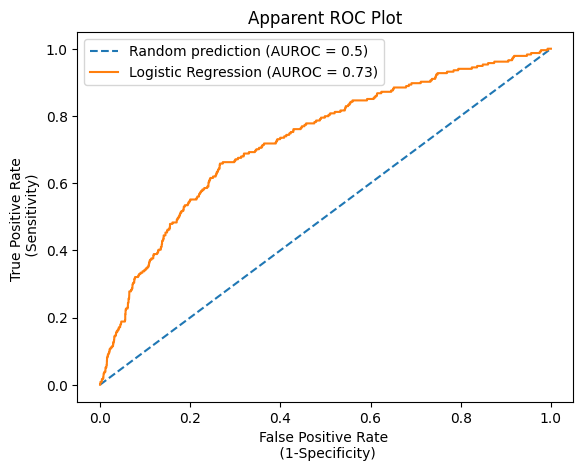

In [9]:
#calculate ROC curve
r_fpr, r_tpr, _ = roc_curve(y,r_probs)
lr_fpr, lr_tpr, _ = roc_curve(y,lr_probs)

#Plot the ROC curve
plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.1f)' % r_auc)
plt.plot(lr_fpr, lr_tpr, label='Logistic Regression (AUROC = %0.2f)' % lr_auc)

plt.title('Apparent ROC Plot')

plt.xlabel('False Positive Rate \n (1-Specificity)')
plt.ylabel('True Positive Rate \n (Sensitivity)')
plt.legend() 
plt.show()

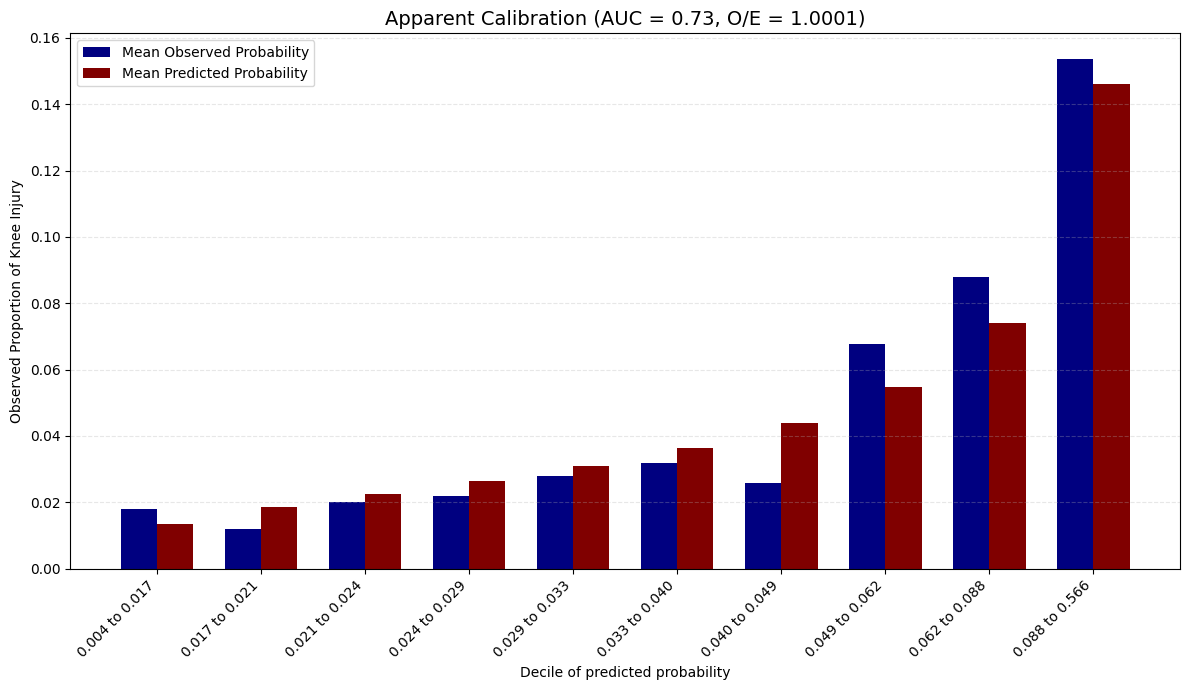

In [10]:
from sklearn.calibration import calibration_curve

# Create a DataFrame with Actual and Predicted values
cal_df = pd.DataFrame({'Actual': y, 'Predicted': lr_probs})

# Bin predictions into 10 deciles (quantiles)
# qcut tries to divide into equal-sized buckets
cal_df['Decile'] = pd.qcut(cal_df['Predicted'], q=10, labels=False, duplicates='drop') + 1

# Group by Decile and calculate means
calibration_data = cal_df.groupby('Decile').agg({
    'Actual': 'mean',
    'Predicted': ['mean', 'min', 'max'] 
}).reset_index()

# Flatten the column names (e.g., ('Predicted', 'min') becomes 'Predicted_min')
calibration_data.columns = ['Decile', 'Observed_Mean', 'Predicted_Mean', 'Predicted_Min', 'Predicted_Max']

#Create the Custom Labels (e.g., "0.004 to 0.017")
calibration_data['Label'] = calibration_data.apply(
    lambda row: f"{row['Predicted_Min']:.3f} to {row['Predicted_Max']:.3f}", axis=1
)

# Sum of actual injuries (Observed)
observed_events = y.sum()
# Sum of predicted probabilities (Expected)
expected_events = lr_probs.sum()
# Ratio
oe_ratio = observed_events / expected_events


#Plotting the Bar Chart
plt.figure(figsize=(12, 7))

#Set bar width and positions
bar_width = 0.35
x = np.arange(len(calibration_data))

# Plot Observed (Navy) and Predicted (Maroon) bars
plt.bar(x - bar_width/2, calibration_data['Observed_Mean'], width=bar_width, label='Mean Observed Probability', color='navy')
plt.bar(x + bar_width/2, calibration_data['Predicted_Mean'], width=bar_width, label='Mean Predicted Probability', color='maroon')

# Formatting
plt.xlabel('Decile of predicted probability')
plt.ylabel('Observed Proportion of Knee Injury')
plt.title(f'Apparent Calibration (AUC = {lr_auc:.2f}, O/E = {oe_ratio:.4f})', fontsize=14)
plt.xticks(x, calibration_data['Label'], rotation=45, ha='right') # Rotate labels to fit
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout() # Adjusts margins so labels aren't cut off
plt.show()



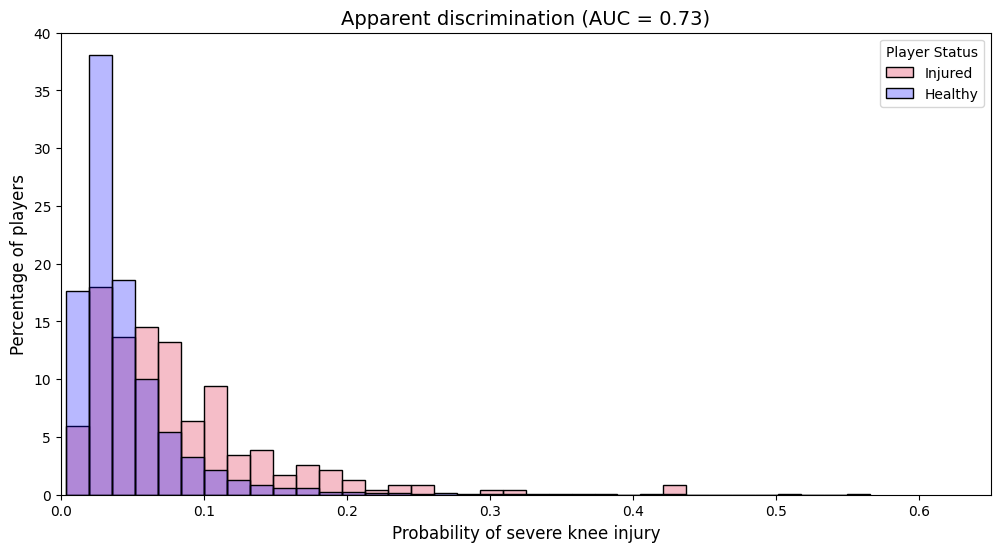

In [11]:
p = model.predict_proba(X)
plot_df = pd.DataFrame({
    'Actual_Class': y,
    'Predicted_Probability': p[:, 1]
})

plot_df['Actual_Class'] = plot_df['Actual_Class'].map({0: 'Healthy', 1: 'Injured'})

plt.figure(figsize=(12, 6))

sns.histplot(
    data=plot_df,
    x='Predicted_Probability',
    hue='Actual_Class',
    stat='percent',
    common_norm=False,
    kde=False,
    palette={"Healthy": "blue", "Injured": "crimson"}, 
    element="bars",
    fill=True,
    alpha=0.28,
    bins=35,
)


plt.xlabel('Probability of severe knee injury', fontsize=12)
plt.ylabel('Percentage of players', fontsize=12)
plt.ylim(0, 40)
plt.xlim(0, 0.65)
plt.legend(title='Player Status', labels=['Injured', 'Healthy'])
plt.title(f'Apparent discrimination (AUC = {lr_auc:.2f})', fontsize=14)

plt.show()

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=2004)

# This trains the model 10 times. For each fold, it predicts the probability for the hold-out set
y_pred_cv = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

# Calculate AUC to verify performance
auc = roc_auc_score(y, y_pred_cv)
print(f"10-Fold Cross-Validated AUC: {auc:.4f}")


c:\Users\Giannis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\Giannis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\Giannis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\Giannis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\Giannis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C a

10-Fold Cross-Validated AUC: 0.7022


c:\Users\Giannis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


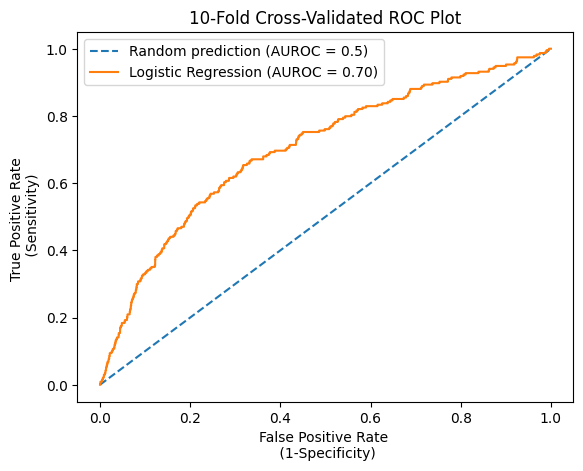

In [13]:
#Calculate and plot the cross-validated ROC curve
r_fpr, r_tpr, _ = roc_curve(y,r_probs)
lrcv_fpr, lrcv_tpr, _ = roc_curve(y,y_pred_cv)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.1f)' % r_auc)
plt.plot(lrcv_fpr, lrcv_tpr, label='Logistic Regression (AUROC = %0.2f)' % auc)

plt.title('10-Fold Cross-Validated ROC Plot')

plt.xlabel('False Positive Rate \n (1-Specificity)')
plt.ylabel('True Positive Rate \n (Sensitivity)')

plt.legend() 
plt.show()

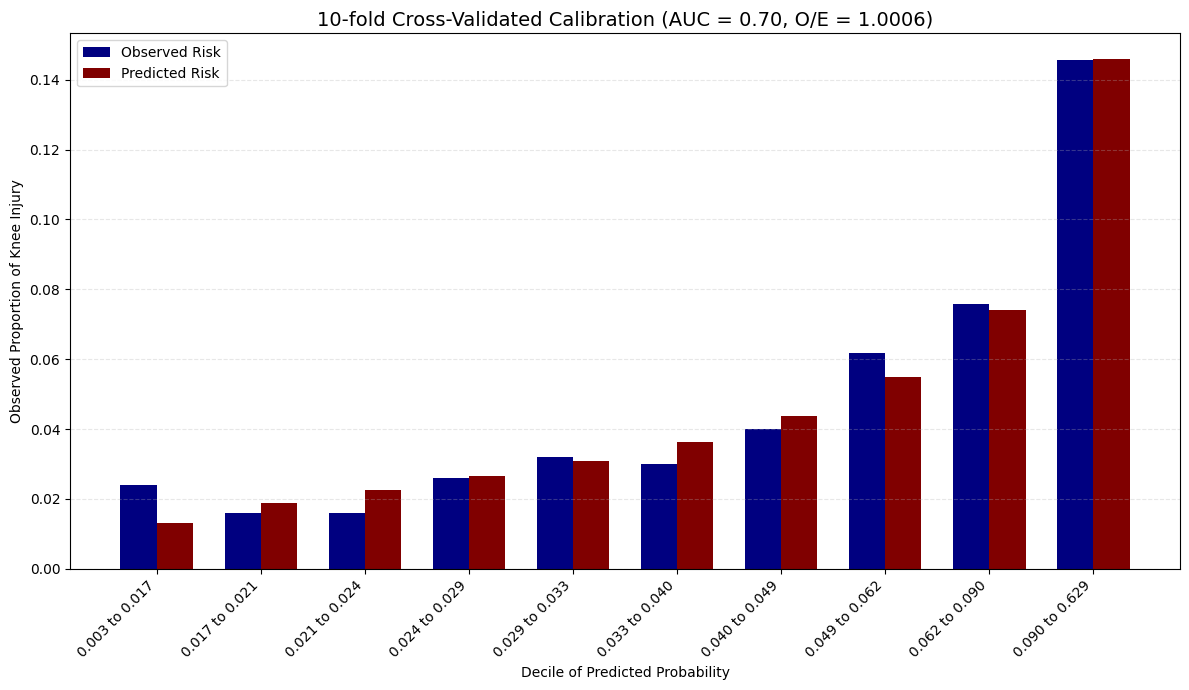

In [14]:
# Prepare Calibration Data
cal_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred_cv})

# Create Deciles
cal_df['Decile'] = pd.qcut(cal_df['Predicted'], q=10, labels=False, duplicates='drop')

# Aggregate data for the plot
calibration_data = cal_df.groupby('Decile').agg({
    'Actual': 'mean',                     # Observed Risk
    'Predicted': ['mean', 'min', 'max']   # Predicted Stats
}).reset_index()

# Flatten columns
calibration_data.columns = ['Decile', 'Observed_Mean', 'Predicted_Mean', 'Predicted_Min', 'Predicted_Max']

# Create Range Labels (e.g., "0.004 to 0.017")
calibration_data['Label'] = calibration_data.apply(
    lambda row: f"{row['Predicted_Min']:.3f} to {row['Predicted_Max']:.3f}", axis=1
)

# Sum of actual injuries (Observed)
observed_events = y.sum()
# Sum of predicted probabilities (Expected)
expected_events_cv = y_pred_cv.sum()
# Ratio
oe_ratio_cv = observed_events / expected_events_cv

# Plotting the Calibration Bar Chart
plt.figure(figsize=(12, 7))

bar_width = 0.35
x = np.arange(len(calibration_data))

plt.bar(x - bar_width/2, calibration_data['Observed_Mean'], width=bar_width, label='Observed Risk', color='navy')
plt.bar(x + bar_width/2, calibration_data['Predicted_Mean'], width=bar_width, label='Predicted Risk', color='maroon')

plt.xlabel('Decile of Predicted Probability')
plt.ylabel('Observed Proportion of Knee Injury')
plt.title(f'10-fold Cross-Validated Calibration (AUC = {auc:.2f}, O/E = {oe_ratio_cv:.4f})', fontsize=14)
plt.xticks(x, calibration_data['Label'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

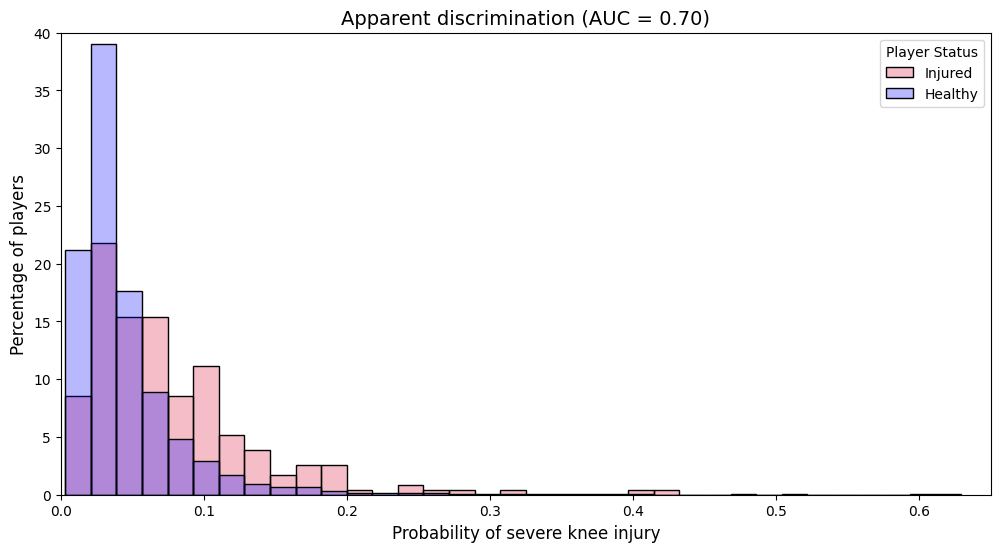

In [ ]:
plot_df_cv = pd.DataFrame({
    'Actual_Class': y,
    'Predicted_Probability': y_pred_cv
})

plt.figure(figsize=(12, 6))

plot_df_cv['Actual_Class'] = plot_df_cv['Actual_Class'].map({0: 'Healthy', 1: 'Injured'})

plt.figure(figsize=(12, 6))

sns.histplot(
    data=plot_df_cv,
    x='Predicted_Probability',
    hue='Actual_Class',
    stat='percent',
    common_norm=False,
    kde=False,
    palette={"Healthy": "blue", "Injured": "crimson"}, 
    element="bars",
    fill=True,
    alpha=0.28,
    bins=35,
)


plt.xlabel('Probability of severe knee injury', fontsize=12)
plt.ylabel('Percentage of players', fontsize=12)
plt.ylim(0, 40)
plt.xlim(0, 0.65)
plt.legend(title='Player Status', labels=['Injured', 'Healthy'])
plt.title(f'10-fold Cross-Validated discrimination (AUC = {auc:.2f})', fontsize=14)

plt.show()